Hệ số tương quan (study_hours vs exam_score): 0.7178


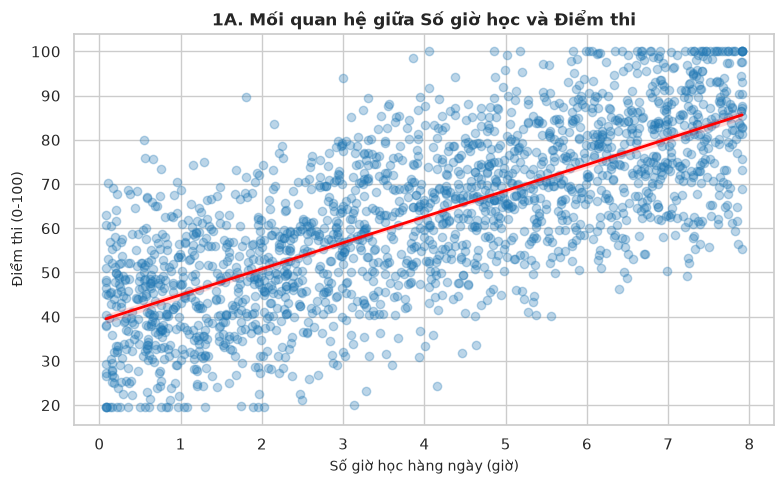

C:\Users\PC\AppData\Local\Temp\ipykernel_14364\2185388015.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=study_stats, x='study_hours_group', y='mean', palette='Blues_d')


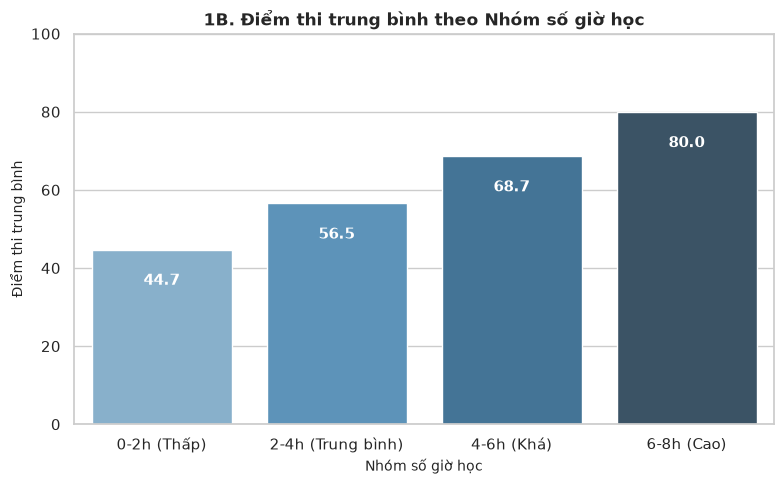

Hệ số tương quan (class_attendance vs exam_score): 0.3089


C:\Users\PC\AppData\Local\Temp\ipykernel_14364\2185388015.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attendance_group', y='exam_score', palette='Greens')


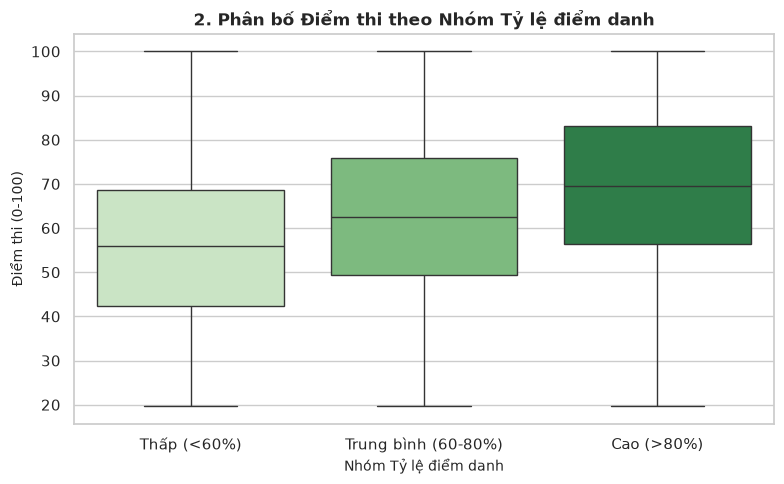

C:\Users\PC\AppData\Local\Temp\ipykernel_14364\2185388015.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df, x='study_method', y='exam_score', order=method_order, palette='Oranges_r', errorbar=None)


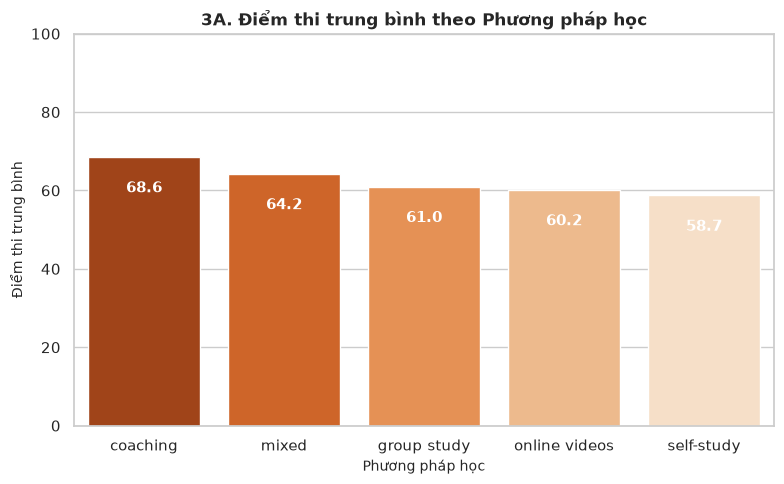

C:\Users\PC\AppData\Local\Temp\ipykernel_14364\2185388015.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='study_method', y='exam_score', order=method_order, palette='Oranges_r')


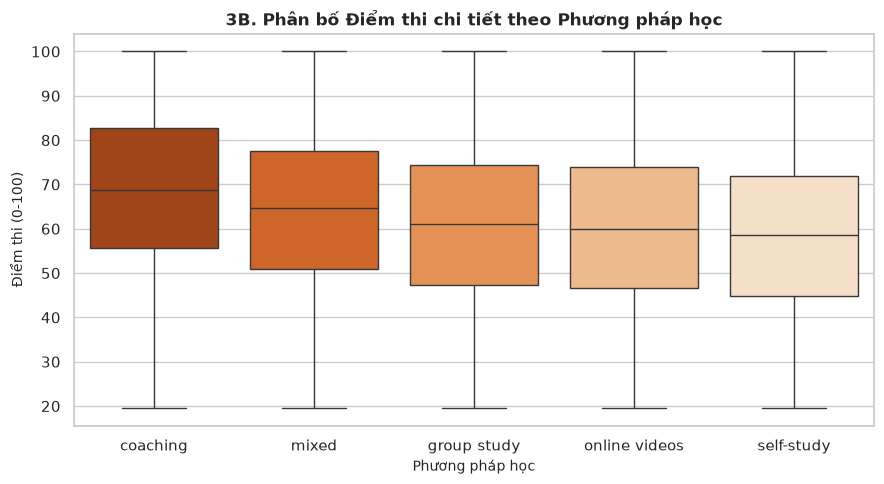

Cột 'sample_papers_practiced' không tồn tại trong file Exam_Score_Prediction.csv.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. ĐỌC DỮ LIỆU GỐC (Dùng cho trực quan hóa trực diện)
# Đọc file dữ liệu từ đúng thư mục data_cleaning
df = pd.read_csv('Exam_Score_Prediction.csv')

# ==========================================
# 1. STUDY HOURS -> EXAM SCORE
# ==========================================
corr_study = df['study_hours'].corr(df['exam_score'])
print(f"Hệ số tương quan (study_hours vs exam_score): {corr_study:.4f}")

# Biểu đồ 1A: Scatter plot + Trendline
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(min(2000, len(df)), random_state=42), 
            x='study_hours', y='exam_score', 
            scatter_kws={'alpha':0.3, 'color':'#1f77b4'}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title('1A. Mối quan hệ giữa Số giờ học và Điểm thi', fontsize=12, fontweight='bold')
plt.xlabel('Số giờ học hàng ngày (giờ)', fontsize=10)
plt.ylabel('Điểm thi (0-100)', fontsize=10)
plt.tight_layout()
plt.savefig('fig1_study_hours_scatter.png', dpi=300)
plt.show()

# Chia nhóm số giờ học & Biểu đồ 1B: Bar chart
df['study_hours_group'] = pd.cut(
    df['study_hours'], 
    bins=[0, 2, 4, 6, 8], 
    labels=['0-2h (Thấp)', '2-4h (Trung bình)', '4-6h (Khá)', '6-8h (Cao)']
)
study_stats = df.groupby('study_hours_group', observed=False)['exam_score'].agg(['count', 'mean', 'std']).reset_index()

plt.figure(figsize=(8, 5))
ax1 = sns.barplot(data=study_stats, x='study_hours_group', y='mean', palette='Blues_d')
plt.title('1B. Điểm thi trung bình theo Nhóm số giờ học', fontsize=12, fontweight='bold')
plt.xlabel('Nhóm số giờ học', fontsize=10)
plt.ylabel('Điểm thi trung bình', fontsize=10)
plt.ylim(0, 100)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                 ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_study_hours_bar.png', dpi=300)
plt.show()

# ==========================================
# 2. CLASS ATTENDANCE -> EXAM SCORE
# ==========================================
corr_attend = df['class_attendance'].corr(df['exam_score'])
print(f"Hệ số tương quan (class_attendance vs exam_score): {corr_attend:.4f}")

df['attendance_group'] = pd.cut(
    df['class_attendance'], 
    bins=[0, 60, 80, 100], 
    labels=['Thấp (<60%)', 'Trung bình (60-80%)', 'Cao (>80%)']
)

# Biểu đồ 2: Boxplot theo tỷ lệ điểm danh
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='attendance_group', y='exam_score', palette='Greens')
plt.title('2. Phân bố Điểm thi theo Nhóm Tỷ lệ điểm danh', fontsize=12, fontweight='bold')
plt.xlabel('Nhóm Tỷ lệ điểm danh', fontsize=10)
plt.ylabel('Điểm thi (0-100)', fontsize=10)
plt.tight_layout()
plt.savefig('fig3_attendance_boxplot.png', dpi=300)
plt.show()

# ==========================================
# 3. STUDY METHOD -> EXAM SCORE
# ==========================================
method_order = df.groupby('study_method')['exam_score'].mean().sort_values(ascending=False).index

# Biểu đồ 3A: Bar chart phương pháp học
plt.figure(figsize=(8, 5))
ax2 = sns.barplot(data=df, x='study_method', y='exam_score', order=method_order, palette='Oranges_r', errorbar=None)
plt.title('3A. Điểm thi trung bình theo Phương pháp học', fontsize=12, fontweight='bold')
plt.xlabel('Phương pháp học', fontsize=10)
plt.ylabel('Điểm thi trung bình', fontsize=10)
plt.ylim(0, 100)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                 ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_study_method_bar.png', dpi=300)
plt.show()

# Biểu đồ 3B: Boxplot phương pháp học
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='study_method', y='exam_score', order=method_order, palette='Oranges_r')
plt.title('3B. Phân bố Điểm thi chi tiết theo Phương pháp học', fontsize=12, fontweight='bold')
plt.xlabel('Phương pháp học', fontsize=10)
plt.ylabel('Điểm thi (0-100)', fontsize=10)
plt.tight_layout()
plt.savefig('fig5_study_method_boxplot.png', dpi=300)
plt.show()

# ==========================================
# 4. KIỂM TRA CỘT SAMPLE PAPERS
# ==========================================
if 'sample_papers_practiced' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='sample_papers_practiced', y='exam_score', palette='Purples')
    plt.title('4. Điểm thi theo Số lượng đề luyện tập', fontsize=12, fontweight='bold')
    plt.xlabel('Số đề luyện tập đã làm', fontsize=10)
    plt.ylabel('Điểm thi (0-100)', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig6_sample_papers_boxplot.png', dpi=300)
    plt.show()
else:
    print("Cột 'sample_papers_practiced' không tồn tại trong file Exam_Score_Prediction.csv.")